# SE3 Electricity Price Forecast — ML Notebook

This notebook builds a day-ahead electricity price forecasting model for the SE3 bidding area (Sweden).

**What we do, step by step:**
1. Fetch historical SE3 prices from ENTSO-E
2. Fetch weather data from Open-Meteo (free, no key needed)
3. Build features: lags, calendar, weather
4. Train a LightGBM model
5. Evaluate: MAE, MAPE, RMSE
6. Plot forecast vs actual
7. Inspect which features matter most (SHAP)

## 0. Install dependencies
Run this cell once. Restart the kernel after installing.

In [1]:
# Run once, then restart kernel
#!pip install entsoe-py lightgbm shap openmeteo-requests requests-cache retry-requests pandas numpy scikit-learn matplotlib plotly

## 1. Config — put your API key here

In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
import os, getpass
ENTSO_E_API_KEY = os.environ.get("ENTSOE_API_KEY") or getpass.getpass("ENTSO-E API key: ")

SE3_AREA_CODE   = "10Y1001A1001A46L"    # SE3 bidding area
WEATHER_LAT     = 59.33                 # Stockholm (centre of SE3)
WEATHER_LON     = 18.07

# How much history to fetch (more = better model, slower download)
TRAIN_START = "2022-01-01"
TRAIN_END   = "2024-12-31"

# Forecast horizon: predict this many hours ahead
FORECAST_HORIZON = 24   # 24h = day-ahead

## 2. Fetch SE3 prices from ENTSO-E
We pull hourly day-ahead prices for SE3 going back to `TRAIN_START`.

In [3]:
import pandas as pd
from entsoe import EntsoePandasClient

client = EntsoePandasClient(api_key=ENTSO_E_API_KEY)

start = pd.Timestamp(TRAIN_START, tz="Europe/Stockholm")
end   = pd.Timestamp(TRAIN_END,   tz="Europe/Stockholm")

print("Fetching prices from ENTSO-E...")
prices = client.query_day_ahead_prices(SE3_AREA_CODE, start=start, end=end)

# Convert to a clean DataFrame
prices = prices.rename("price_eur_mwh").to_frame()
prices.index = prices.index.tz_convert("Europe/Stockholm")
prices.index.name = "timestamp"

print(f"Fetched {len(prices)} hourly price records")
print(f"Price range: {prices.price_eur_mwh.min():.1f} – {prices.price_eur_mwh.max():.1f} EUR/MWh")
prices.head()

Fetching prices from ENTSO-E...
Fetched 26278 hourly price records
Price range: -60.0 – 800.0 EUR/MWh


,price_eur_mwh
timestamp,
2022-01-01 00:00:00+01:00,46.60
2022-01-01 01:00:00+01:00,41.33
2022-01-01 02:00:00+01:00,42.18
2022-01-01 03:00:00+01:00,44.37
2022-01-01 04:00:00+01:00,37.67


## 3. Fetch weather data from Open-Meteo
No API key needed. We pull temperature, wind speed, and solar radiation.

In [4]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

# Set up a cached session so repeated runs don't re-download
cache_session  = requests_cache.CachedSession(".weather_cache", expire_after=-1)
retry_session  = retry(cache_session, retries=5, backoff_factor=0.2)
om_client      = openmeteo_requests.Client(session=retry_session)

params = {
    "latitude":   WEATHER_LAT,
    "longitude":  WEATHER_LON,
    "start_date": TRAIN_START,
    "end_date":   TRAIN_END,
    "hourly": ["temperature_2m", "windspeed_10m", "direct_radiation"],
    "timezone": "Europe/Stockholm",
}

print("Fetching weather from Open-Meteo...")
response = om_client.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)[0]
hourly   = response.Hourly()

weather = pd.DataFrame({
    "timestamp":        pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ).tz_convert("Europe/Stockholm"),
    "temperature":      hourly.Variables(0).ValuesAsNumpy(),
    "windspeed":        hourly.Variables(1).ValuesAsNumpy(),
    "solar_radiation":  hourly.Variables(2).ValuesAsNumpy(),
}).set_index("timestamp")

print(f"Fetched {len(weather)} hourly weather records")
weather.head()

Fetching weather from Open-Meteo...
Fetched 26304 hourly weather records


,temperature,windspeed,solar_radiation
timestamp,,,
2021-12-31 23:00:00+01:00,0.30,13.004922,0.0
2022-01-01 00:00:00+01:00,-1.05,11.753877,0.0
2022-01-01 01:00:00+01:00,-0.65,8.669949,0.0
2022-01-01 02:00:00+01:00,-0.30,10.703569,0.0
2022-01-01 03:00:00+01:00,0.25,14.986553,0.0


## 4. Merge prices + weather

In [5]:
# Join on timestamp, keep only hours where we have both
df = prices.join(weather, how="inner")

# Drop any rows with missing values
df = df.dropna()

print(f"Combined dataset: {len(df)} hours ({df.index.min().date()} → {df.index.max().date()})")
df.head()

Combined dataset: 26278 hours (2022-01-01 → 2024-12-30)


,price_eur_mwh,temperature,windspeed,solar_radiation
timestamp,,,,
2022-01-01 00:00:00+01:00,46.60,-1.05,11.753877,0.0
2022-01-01 01:00:00+01:00,41.33,-0.65,8.669949,0.0
2022-01-01 02:00:00+01:00,42.18,-0.30,10.703569,0.0
2022-01-01 03:00:00+01:00,44.37,0.25,14.986553,0.0
2022-01-01 04:00:00+01:00,37.67,0.40,16.299694,0.0


## 5. Feature engineering

We create three groups of features:
- **Lag features** — past prices that the model can learn from
- **Calendar features** — hour of day, weekday, holidays
- **Weather features** — temperature, wind, solar

In [6]:
import numpy as np
import holidays

se_holidays = holidays.Sweden()

def build_features(df):
    X = df.copy()

    # ── Lag features (past prices) ──────────────────────────────────────────
    X["price_lag_1h"]    = X["price_eur_mwh"].shift(1)    # 1 hour ago
    X["price_lag_24h"]   = X["price_eur_mwh"].shift(24)   # same hour yesterday
    X["price_lag_168h"]  = X["price_eur_mwh"].shift(168)  # same hour last week
    X["price_lag_48h"]   = X["price_eur_mwh"].shift(48)   # same hour 2 days ago

    # Rolling average over last 24h and 7 days
    X["price_roll_24h_mean"] = X["price_eur_mwh"].shift(1).rolling(24).mean()
    X["price_roll_168h_mean"]= X["price_eur_mwh"].shift(1).rolling(168).mean()

    # ── Calendar features ───────────────────────────────────────────────────
    X["hour"]        = X.index.hour
    X["dayofweek"]   = X.index.dayofweek        # 0=Monday, 6=Sunday
    X["month"]       = X.index.month
    X["is_weekend"]  = (X.index.dayofweek >= 5).astype(int)
    X["is_holiday"]  = X.index.normalize().map(lambda d: int(d in se_holidays))

    # Peak hour flag: morning (07-09) and evening (17-20)
    X["is_peak"] = X["hour"].isin(range(7, 10)).astype(int) | \
                   X["hour"].isin(range(17, 21)).astype(int)

    # Season (1=winter, 2=spring, 3=summer, 4=autumn)
    X["season"] = X["month"].map(
        {12:1, 1:1, 2:1, 3:2, 4:2, 5:2, 6:3, 7:3, 8:3, 9:4, 10:4, 11:4}
    )

    return X

df = build_features(df)

# Drop rows where lags are NaN (first ~168 rows)
df = df.dropna()

print(f"Features built. Dataset size after dropping NaN lags: {len(df)} rows")
print(f"Columns: {list(df.columns)}")

Features built. Dataset size after dropping NaN lags: 26110 rows
Columns: ['price_eur_mwh', 'temperature', 'windspeed', 'solar_radiation', 'price_lag_1h', 'price_lag_24h', 'price_lag_168h', 'price_lag_48h', 'price_roll_24h_mean', 'price_roll_168h_mean', 'hour', 'dayofweek', 'month', 'is_weekend', 'is_holiday', 'is_peak', 'season']


## 6. Train / test split
We keep the last 90 days as a test set. Everything before is training data.

In [ ]:
FEATURE_COLS = [
    "price_lag_24h", "price_lag_48h", "price_lag_168h",
     "price_roll_168h_mean",
    "hour", "dayofweek", "month", "season",
    "is_weekend", "is_holiday", "is_peak",
    "temperature", "windspeed", "solar_radiation",
]
TARGET_COL = "price_eur_mwh"

# Split: last 90 days = test
split_date = df.index.max() - pd.Timedelta(days=90)

train = df[df.index <= split_date]
test  = df[df.index >  split_date]

X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

print(f"Training set:  {len(train)} hours ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test set:      {len(test)}  hours ({test.index.min().date()}  → {test.index.max().date()})")

Training set:  23950 hours (2022-01-08 → 2024-10-02)
Test set:      2160  hours (2024-10-02  → 2024-12-30)


## 7. Train LightGBM model
We train three models: median forecast (q50) and a confidence band (q10 / q90).

In [15]:
import lightgbm as lgb

# Shared parameters
BASE_PARAMS = {
    "n_estimators":    500,
    "learning_rate":   0.05,
    "num_leaves":      63,
    "min_child_samples": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq":    5,
    "verbose":        -1,
}

# Median forecast
model_p50 = lgb.LGBMRegressor(objective="quantile", alpha=0.50, **BASE_PARAMS)
# Lower bound (10th percentile)
model_p10 = lgb.LGBMRegressor(objective="quantile", alpha=0.10, **BASE_PARAMS)
# Upper bound (90th percentile)
model_p90 = lgb.LGBMRegressor(objective="quantile", alpha=0.90, **BASE_PARAMS)

print("Training models...")
model_p50.fit(X_train, y_train)
model_p10.fit(X_train, y_train)
model_p90.fit(X_train, y_train)
print("Done!")

Training models...
Done!


## 8. Evaluate on the test set

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

pred_p50 = model_p50.predict(X_test)
pred_p10 = model_p10.predict(X_test)
pred_p90 = model_p90.predict(X_test)

mae  = mean_absolute_error(y_test, pred_p50)
rmse = mean_squared_error(y_test, pred_p50, squared=False)

# MAPE — skip hours where actual price is near 0 to avoid division errors
mask = y_test.abs() > 1
mape = (((y_test[mask] - pred_p50[mask]).abs() / y_test[mask].abs()).mean()) * 100

# Coverage: how often does actual fall inside the 10-90 band?
coverage = ((y_test >= pred_p10) & (y_test <= pred_p90)).mean() * 100

print("=" * 40)
print(f"  MAE      : {mae:.2f}  EUR/MWh")
print(f"  RMSE     : {rmse:.2f}  EUR/MWh")
print(f"  MAPE     : {mape:.1f}%")
print(f"  PI Coverage (q10–q90): {coverage:.1f}%  (ideal ~80%)")
print("=" * 40)

  MAE      : 17.05  EUR/MWh
  RMSE     : 32.29  EUR/MWh
  MAPE     : 89.6%
  PI Coverage (q10–q90): 53.2%  (ideal ~80%)


## 9. Plot: forecast vs actual
We zoom into the last 2 weeks of the test set so the chart is readable.

In [17]:
import plotly.graph_objects as go

# Last 14 days of test set
plot_df = test.copy().iloc[-14*24:]
p50_plot = model_p50.predict(plot_df[FEATURE_COLS])
p10_plot = model_p10.predict(plot_df[FEATURE_COLS])
p90_plot = model_p90.predict(plot_df[FEATURE_COLS])

fig = go.Figure()

# Confidence band (shaded area between p10 and p90)
fig.add_trace(go.Scatter(
    x=list(plot_df.index) + list(plot_df.index[::-1]),
    y=list(p90_plot) + list(p10_plot[::-1]),
    fill="toself", fillcolor="rgba(99,153,255,0.15)",
    line=dict(color="rgba(0,0,0,0)"),
    name="80% confidence band"
))

# Actual prices
fig.add_trace(go.Scatter(
    x=plot_df.index, y=plot_df["price_eur_mwh"],
    name="Actual", line=dict(color="#333", width=1.5)
))

# Forecast (median)
fig.add_trace(go.Scatter(
    x=plot_df.index, y=p50_plot,
    name="Forecast (median)", line=dict(color="#2563eb", width=2)
))

fig.update_layout(
    title="SE3 Day-Ahead Price — Actual vs Forecast (last 14 days of test set)",
    xaxis_title="Time",
    yaxis_title="EUR/MWh",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    hovermode="x unified",
    template="plotly_white",
    height=450,
)
fig.show()

## 10. Feature importance with SHAP
SHAP tells us which features push the price up or down for each prediction.

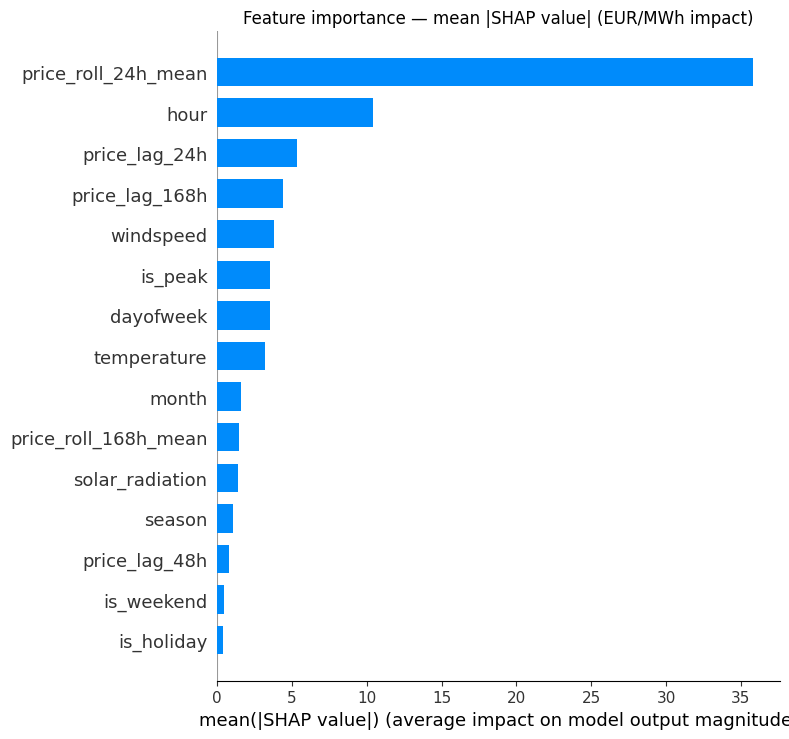

In [18]:
import shap
import matplotlib.pyplot as plt

# Use a sample of 500 rows to keep it fast
sample = X_test.sample(500, random_state=42)

explainer   = shap.TreeExplainer(model_p50)
shap_values = explainer.shap_values(sample)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, sample, plot_type="bar", show=False)
plt.title("Feature importance — mean |SHAP value| (EUR/MWh impact)")
plt.tight_layout()
plt.show()

## 11. Save the model
We save everything needed to make a forecast later — the model and the feature column list.

In [19]:
import pickle, json, os

os.makedirs("model", exist_ok=True)

# Save the three quantile models
with open("model/model_p10.pkl", "wb") as f: pickle.dump(model_p10, f)
with open("model/model_p50.pkl", "wb") as f: pickle.dump(model_p50, f)
with open("model/model_p90.pkl", "wb") as f: pickle.dump(model_p90, f)

# Save feature config so the Streamlit app uses the same columns
with open("model/feature_config.json", "w") as f:
    json.dump({"feature_cols": FEATURE_COLS, "target_col": TARGET_COL}, f, indent=2)

print("Saved to model/")
print(f"  model_p10.pkl  — lower bound (10th percentile)")
print(f"  model_p50.pkl  — median forecast")
print(f"  model_p90.pkl  — upper bound (90th percentile)")
print(f"  feature_config.json")

Saved to model/
  model_p10.pkl  — lower bound (10th percentile)
  model_p50.pkl  — median forecast
  model_p90.pkl  — upper bound (90th percentile)
  feature_config.json


## 12. Make a forecast for the next 24 hours
This shows how to use the saved model to produce a fresh forecast.

In [20]:
# The last 168 rows of df give us all the lag values we need
# In production this would be the most recent 168h from the database
recent = df.tail(168 + 24).copy()
recent = build_features(recent).dropna()

# Take the last 24 rows = next 24 hours
forecast_input = recent.tail(24)[FEATURE_COLS]

forecast = pd.DataFrame({
    "hour":        forecast_input.index,
    "forecast_p10": model_p10.predict(forecast_input),
    "forecast_p50": model_p50.predict(forecast_input),
    "forecast_p90": model_p90.predict(forecast_input),
}).set_index("hour")

print("Next 24h SE3 price forecast (EUR/MWh):")
print(forecast.round(1).to_string())

Next 24h SE3 price forecast (EUR/MWh):
                           forecast_p10  forecast_p50  forecast_p90
hour                                                               
2024-12-30 00:00:00+01:00          -1.7          -0.7           4.5
2024-12-30 01:00:00+01:00          -2.9          -2.1           3.5
2024-12-30 02:00:00+01:00          -3.5           0.2           5.6
2024-12-30 03:00:00+01:00          -1.4           1.7           5.8
2024-12-30 04:00:00+01:00          -0.5           1.9           9.5
2024-12-30 05:00:00+01:00           1.3           3.5          17.0
2024-12-30 06:00:00+01:00           3.6           7.1          23.2
2024-12-30 07:00:00+01:00           6.3          17.0          40.3
2024-12-30 08:00:00+01:00           7.6          20.3          41.4
2024-12-30 09:00:00+01:00           7.8          17.2          39.2
2024-12-30 10:00:00+01:00           8.9          15.6          29.9
2024-12-30 11:00:00+01:00           9.5          15.7          33.3
2024-12-3

---
## Next steps
- Add ENTSO-E generation features (hydro, wind, nuclear) for better accuracy
- Tune hyperparameters with Optuna
- Package the model into a Cloud Function for daily retraining
- Build the Streamlit dashboard on top of this model